IYR data loaded successfully.
Shape: (3774, 7)


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-01-04,46.450001,46.660000,45.529999,45.810001,26.637310,16952700
1,2010-01-05,45.810001,45.959999,45.290001,45.919998,26.701263,14523000
2,2010-01-06,45.939999,46.230000,45.709999,45.900002,26.689632,14859100
3,2010-01-07,45.869999,46.520000,45.369999,46.310001,26.928043,16364700
4,2010-01-08,46.189999,46.230000,45.590000,46.000000,26.747786,10629500


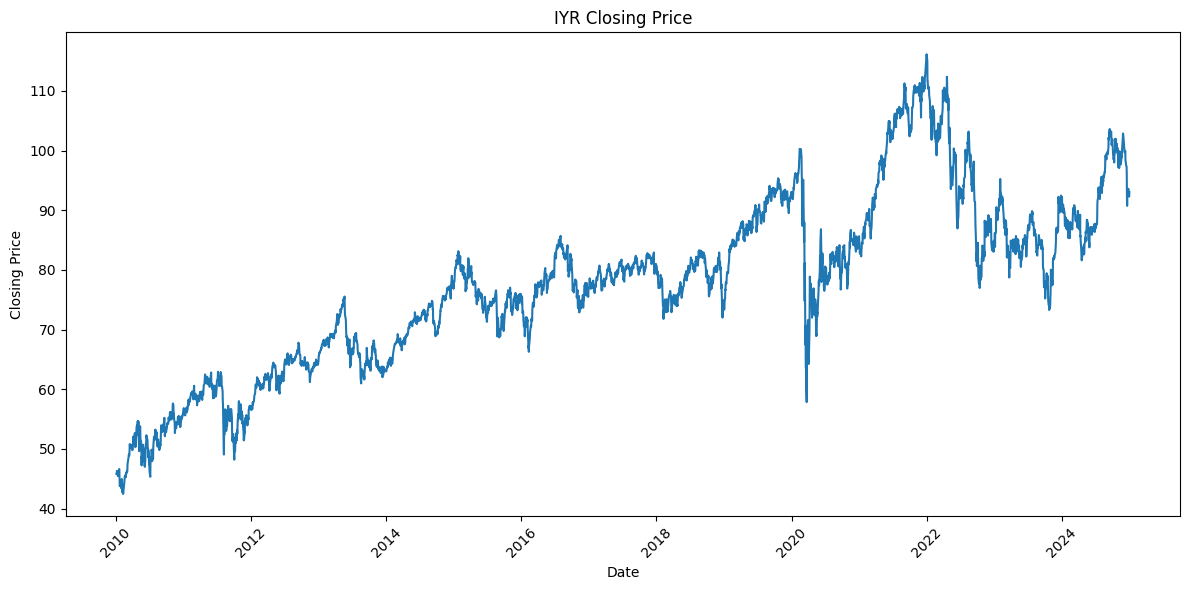

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

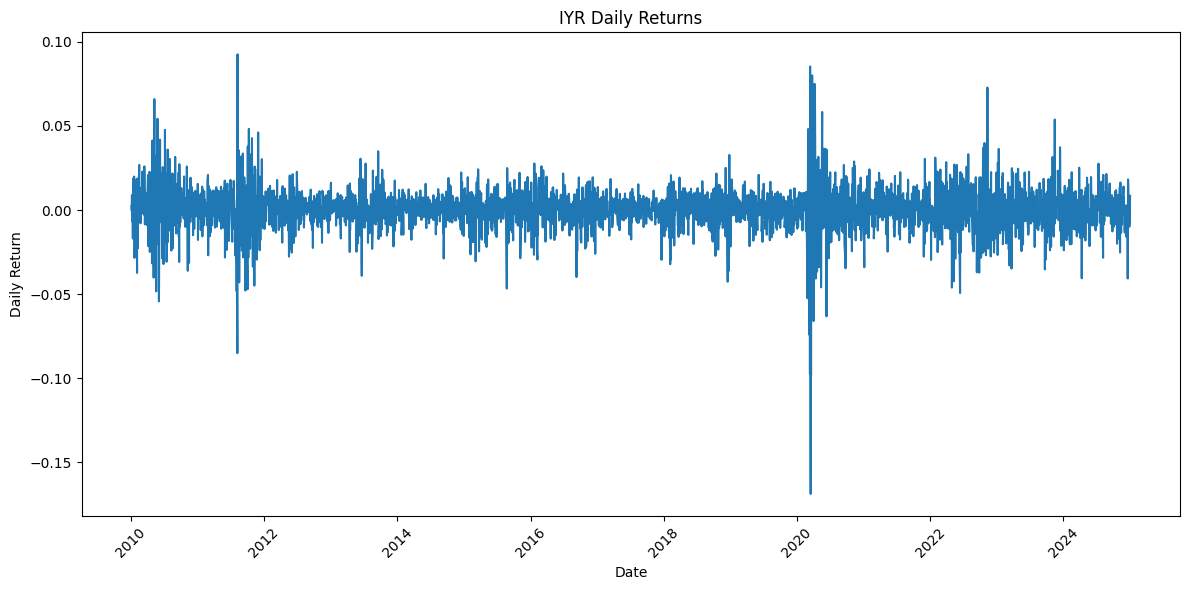

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

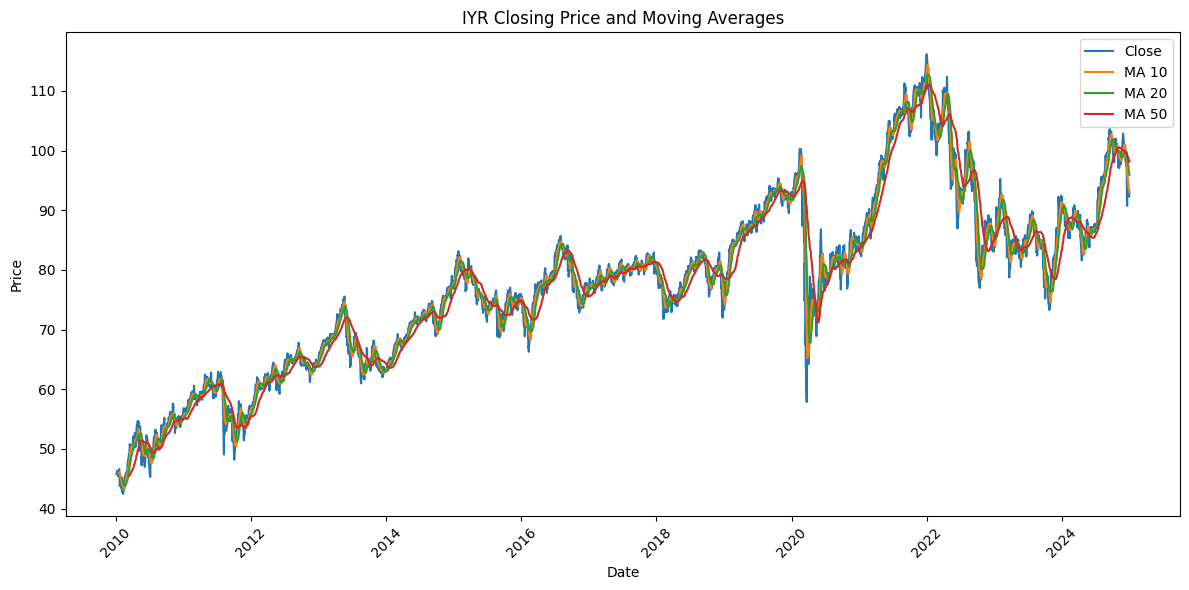

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

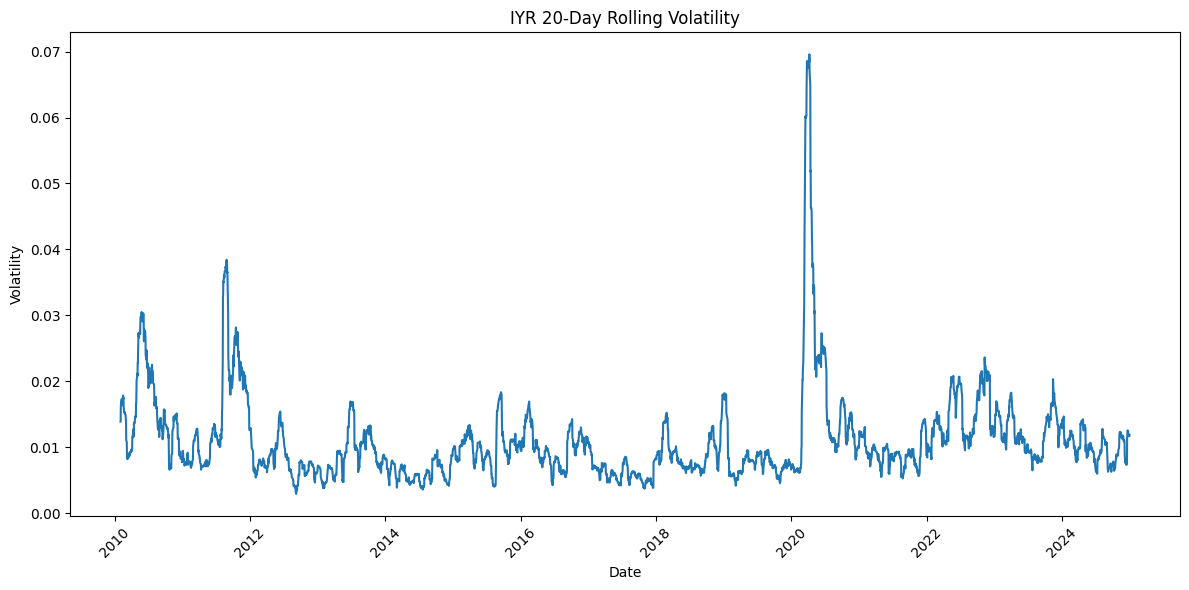

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

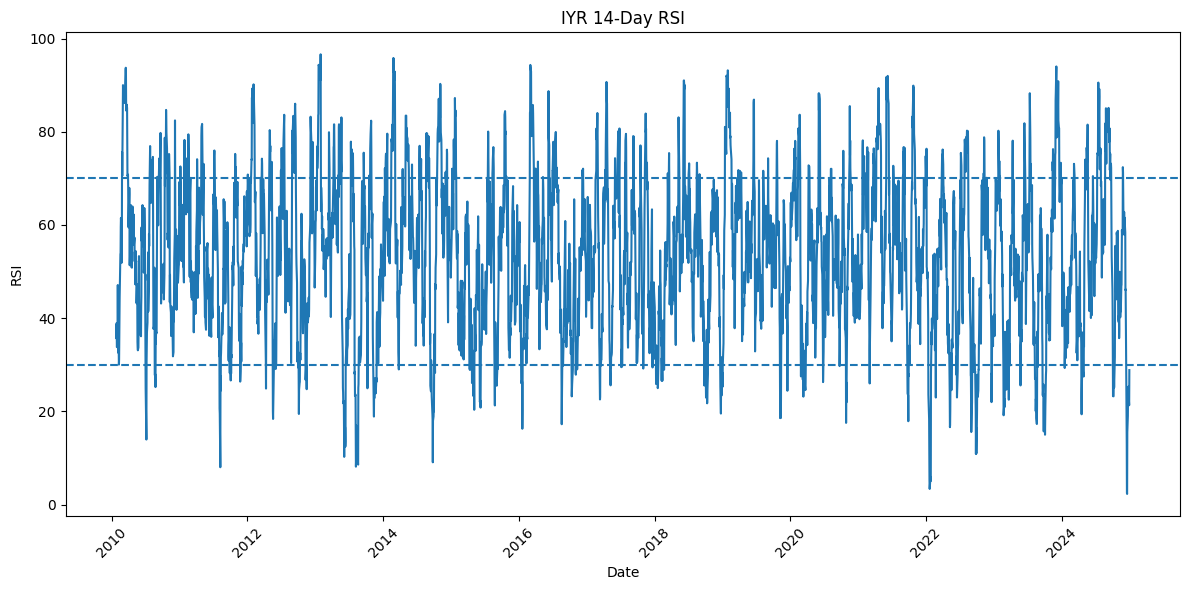

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

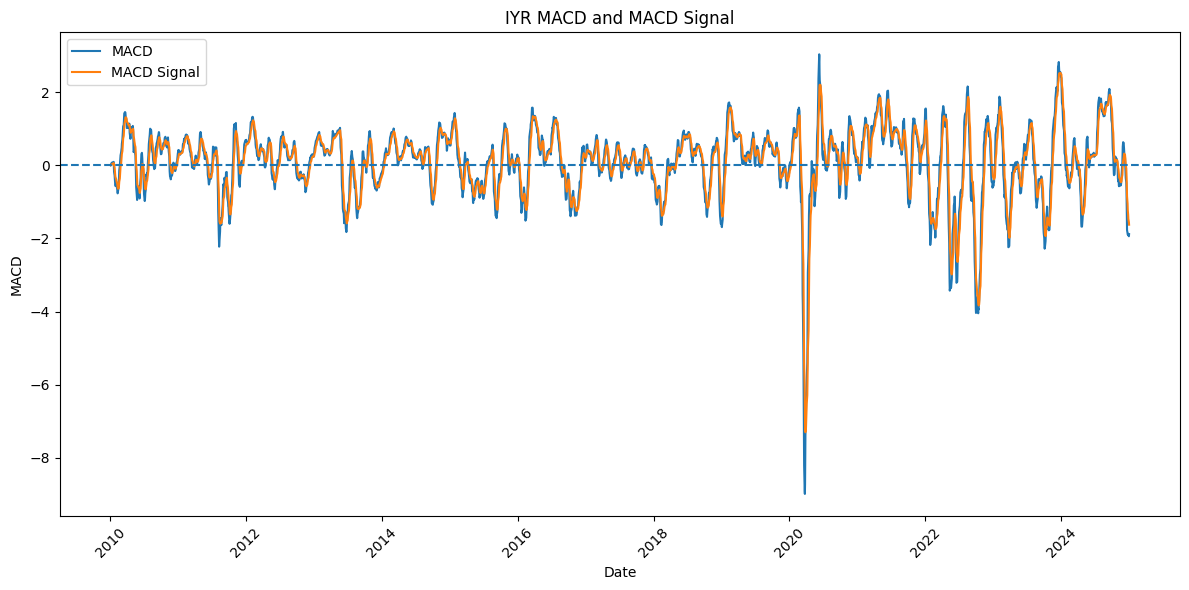

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Processed IYR shape: (3725, 15)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Training samples: 2979
Testing samples: 745
IYR model training completed successfully.
IYR prediction completed successfully.


IYR MODEL EVALUATION RESULTS
MAE  : 0.9097
MSE  : 1.4339
RMSE : 1.1975
R²   : 0.9785


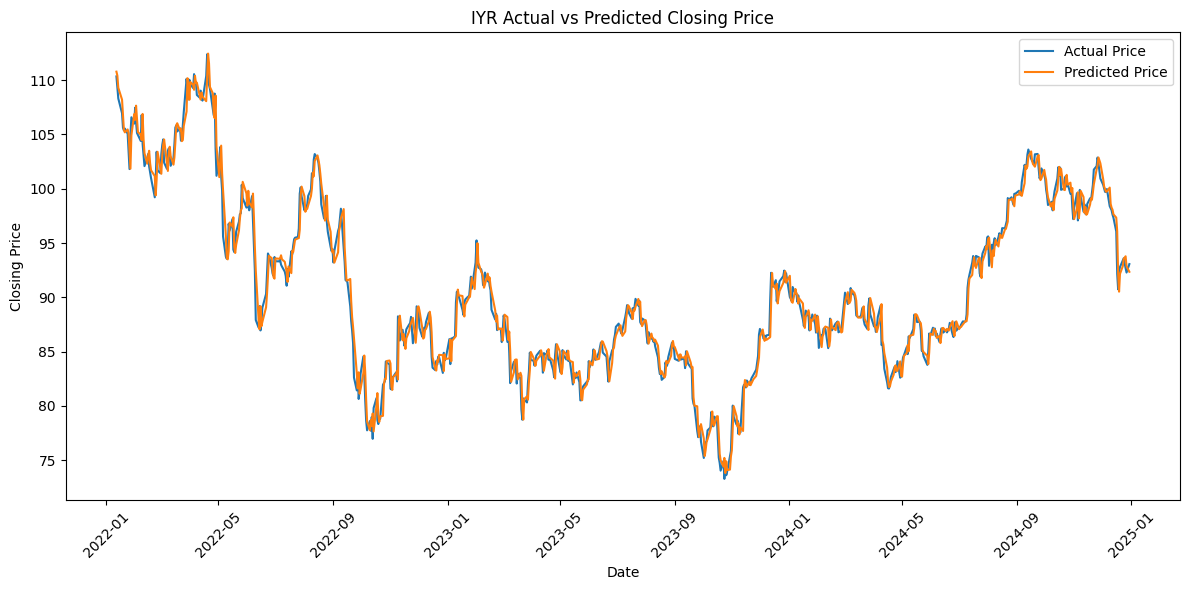

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


IYR COMPLETE WORKFLOW FINISHED SUCCESSFULLY.


In [6]:
# ============================================================
# IYR COMPLETE DATA SCIENCE WORKFLOW
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

df_iyr = pd.read_csv("IYR.csv")

df_iyr["Date"] = pd.to_datetime(df_iyr["Date"])

df_iyr = (
    df_iyr
    .sort_values("Date")
    .drop_duplicates(subset=["Date"])
    .reset_index(drop=True)
)

print("IYR data loaded successfully.")
print("Shape:", df_iyr.shape)

display(df_iyr.head())


# ------------------------------------------------------------
# 2. DAILY RETURN
# ------------------------------------------------------------

df_iyr["Daily_Return"] = df_iyr["Close"].pct_change()


# ------------------------------------------------------------
# 3. MOVING AVERAGES
# ------------------------------------------------------------

df_iyr["MA_10"] = df_iyr["Close"].rolling(10).mean()
df_iyr["MA_20"] = df_iyr["Close"].rolling(20).mean()
df_iyr["MA_50"] = df_iyr["Close"].rolling(50).mean()


# ------------------------------------------------------------
# 4. VOLATILITY
# ------------------------------------------------------------

df_iyr["Volatility_20"] = (
    df_iyr["Daily_Return"].rolling(20).std()
)


# ------------------------------------------------------------
# 5. RSI
# ------------------------------------------------------------

delta = df_iyr["Close"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

df_iyr["RSI_14"] = 100 - (100 / (1 + rs))


# ------------------------------------------------------------
# 6. MACD
# ------------------------------------------------------------

ema_12 = df_iyr["Close"].ewm(
    span=12,
    adjust=False
).mean()

ema_26 = df_iyr["Close"].ewm(
    span=26,
    adjust=False
).mean()

df_iyr["MACD"] = ema_12 - ema_26

df_iyr["MACD_Signal"] = (
    df_iyr["MACD"]
    .ewm(span=9, adjust=False)
    .mean()
)


# ------------------------------------------------------------
# 7. SAVE FIGURES
# ------------------------------------------------------------

# Closing Price
plt.figure(figsize=(12, 6))
plt.plot(df_iyr["Date"], df_iyr["Close"])
plt.title("IYR Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)
plt.tight_layout()

file_path = "IYR_Closing_Price.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()
files.download(file_path)


# Daily Returns
plt.figure(figsize=(12, 6))
plt.plot(df_iyr["Date"], df_iyr["Daily_Return"])
plt.title("IYR Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.xticks(rotation=45)
plt.tight_layout()

file_path = "IYR_Daily_Returns.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()
files.download(file_path)


# Moving Averages
plt.figure(figsize=(12, 6))
plt.plot(df_iyr["Date"], df_iyr["Close"], label="Close")
plt.plot(df_iyr["Date"], df_iyr["MA_10"], label="MA 10")
plt.plot(df_iyr["Date"], df_iyr["MA_20"], label="MA 20")
plt.plot(df_iyr["Date"], df_iyr["MA_50"], label="MA 50")
plt.title("IYR Closing Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

file_path = "IYR_Moving_Averages.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()
files.download(file_path)


# Volatility
plt.figure(figsize=(12, 6))
plt.plot(
    df_iyr["Date"],
    df_iyr["Volatility_20"]
)
plt.title("IYR 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.xticks(rotation=45)
plt.tight_layout()

file_path = "IYR_Volatility_20.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()
files.download(file_path)


# RSI
plt.figure(figsize=(12, 6))
plt.plot(
    df_iyr["Date"],
    df_iyr["RSI_14"]
)
plt.axhline(70, linestyle="--")
plt.axhline(30, linestyle="--")
plt.title("IYR 14-Day RSI")
plt.xlabel("Date")
plt.ylabel("RSI")
plt.xticks(rotation=45)
plt.tight_layout()

file_path = "IYR_RSI_14.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()
files.download(file_path)


# MACD
plt.figure(figsize=(12, 6))
plt.plot(
    df_iyr["Date"],
    df_iyr["MACD"],
    label="MACD"
)
plt.plot(
    df_iyr["Date"],
    df_iyr["MACD_Signal"],
    label="MACD Signal"
)
plt.axhline(0, linestyle="--")
plt.title("IYR MACD and MACD Signal")
plt.xlabel("Date")
plt.ylabel("MACD")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

file_path = "IYR_MACD.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()
files.download(file_path)


# ------------------------------------------------------------
# 8. PROCESSED DATASET
# ------------------------------------------------------------

feature_columns = [
    "Date",
    "Open",
    "High",
    "Low",
    "Close",
    "Adj Close",
    "Volume",
    "Daily_Return",
    "MA_10",
    "MA_20",
    "MA_50",
    "Volatility_20",
    "RSI_14",
    "MACD",
    "MACD_Signal"
]

df_iyr_features = (
    df_iyr[feature_columns]
    .dropna()
    .reset_index(drop=True)
)

print("Processed IYR shape:", df_iyr_features.shape)

df_iyr_features.to_csv(
    "IYR_features.csv",
    index=False
)

files.download("IYR_features.csv")


# ------------------------------------------------------------
# 9. TARGET
# ------------------------------------------------------------

df_ml_iyr = df_iyr_features.copy()

df_ml_iyr["Target"] = (
    df_ml_iyr["Close"].shift(-1)
)

df_ml_iyr = (
    df_ml_iyr
    .dropna()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 10. FEATURES FOR MODEL
# ------------------------------------------------------------

model_features = [
    "Close",
    "Daily_Return",
    "MA_10",
    "MA_20",
    "MA_50",
    "Volatility_20",
    "RSI_14",
    "MACD",
    "MACD_Signal"
]

X = df_ml_iyr[model_features]
y = df_ml_iyr["Target"]


# ------------------------------------------------------------
# 11. TIME-SERIES TRAIN/TEST SPLIT
# ------------------------------------------------------------

split_index = int(len(df_ml_iyr) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


# ------------------------------------------------------------
# 12. SCALING
# ------------------------------------------------------------

scaler_iyr = StandardScaler()

X_train_scaled = scaler_iyr.fit_transform(X_train)
X_test_scaled = scaler_iyr.transform(X_test)


# ------------------------------------------------------------
# 13. TRAIN MODEL
# ------------------------------------------------------------

model_iyr = LinearRegression()

model_iyr.fit(
    X_train_scaled,
    y_train
)

print("IYR model training completed successfully.")


# ------------------------------------------------------------
# 14. PREDICTION
# ------------------------------------------------------------

y_pred_iyr = model_iyr.predict(
    X_test_scaled
)

print("IYR prediction completed successfully.")


# ------------------------------------------------------------
# 15. EVALUATION
# ------------------------------------------------------------

actual_iyr = np.array(y_test)
predicted_iyr = np.array(y_pred_iyr)

mae_iyr = mean_absolute_error(
    actual_iyr,
    predicted_iyr
)

mse_iyr = mean_squared_error(
    actual_iyr,
    predicted_iyr
)

rmse_iyr = np.sqrt(mse_iyr)

r2_iyr = r2_score(
    actual_iyr,
    predicted_iyr
)

print("\n")
print("=" * 50)
print("IYR MODEL EVALUATION RESULTS")
print("=" * 50)
print(f"MAE  : {mae_iyr:.4f}")
print(f"MSE  : {mse_iyr:.4f}")
print(f"RMSE : {rmse_iyr:.4f}")
print(f"R²   : {r2_iyr:.4f}")
print("=" * 50)


# ------------------------------------------------------------
# 16. ACTUAL VS PREDICTED
# ------------------------------------------------------------

test_dates_iyr = (
    df_ml_iyr["Date"]
    .iloc[split_index:]
    .reset_index(drop=True)
)

plt.figure(figsize=(12, 6))

plt.plot(
    test_dates_iyr,
    actual_iyr,
    label="Actual Price"
)

plt.plot(
    test_dates_iyr,
    predicted_iyr,
    label="Predicted Price"
)

plt.title("IYR Actual vs Predicted Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()

file_path = "IYR_Actual_vs_Predicted.png"

plt.savefig(
    file_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

files.download(file_path)


# ------------------------------------------------------------
# 17. SAVE EVALUATION
# ------------------------------------------------------------

evaluation_iyr = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R2"
    ],
    "Value": [
        mae_iyr,
        mse_iyr,
        rmse_iyr,
        r2_iyr
    ]
})

evaluation_iyr.to_csv(
    "IYR_Evaluation_Metrics.csv",
    index=False
)

files.download(
    "IYR_Evaluation_Metrics.csv"
)


# ------------------------------------------------------------
# 18. SAVE PREDICTIONS
# ------------------------------------------------------------

prediction_iyr = pd.DataFrame({
    "Date": test_dates_iyr,
    "Actual": actual_iyr,
    "Predicted": predicted_iyr
})

prediction_iyr["Error"] = (
    prediction_iyr["Actual"] -
    prediction_iyr["Predicted"]
)

prediction_iyr.to_csv(
    "IYR_Prediction_Results.csv",
    index=False
)

files.download(
    "IYR_Prediction_Results.csv"
)


print("\nIYR COMPLETE WORKFLOW FINISHED SUCCESSFULLY.")